Saved rebuilt summary CSV with 166 models: test_eval_outputs/model_test_summary.csv


================ OFFICIAL / BASELINE MODELS ================
Rows: 46

=== Architecture family summary ===
  arch_family  n_models  mean_metric  median_metric  best_metric  \
0   prof_unet        10     0.100953       0.096613     0.005969   
2        unet        18     0.152010       0.103255     0.007806   
1    splitnet        18     0.175930       0.153075     0.005909   

   worst_metric  std_metric  
0      0.166391    0.042451  
2      0.623921    0.142609  
1      0.484931    0.095381  


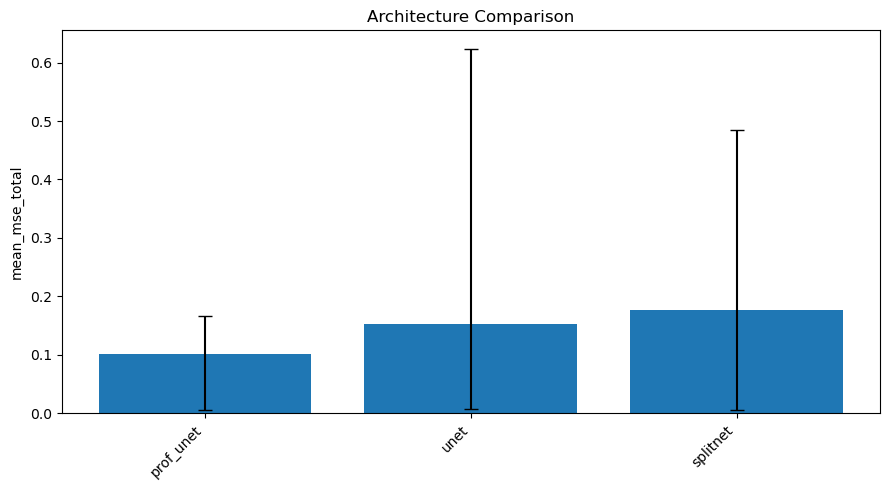


=== Attention effect summary ===
  arch_family  has_attention  n_models  mean_metric  median_metric  \
3        unet           True        10     0.102691       0.096430   
1    splitnet           True        10     0.140832       0.138855   
2        unet          False         8     0.213658       0.121379   
0    splitnet          False         8     0.219803       0.173252   

   best_metric  worst_metric  std_metric  
3     0.007806      0.233621    0.056505  
1     0.005909      0.243830    0.063603  
2     0.093911      0.623921    0.193565  
0     0.146727      0.484931    0.113723  


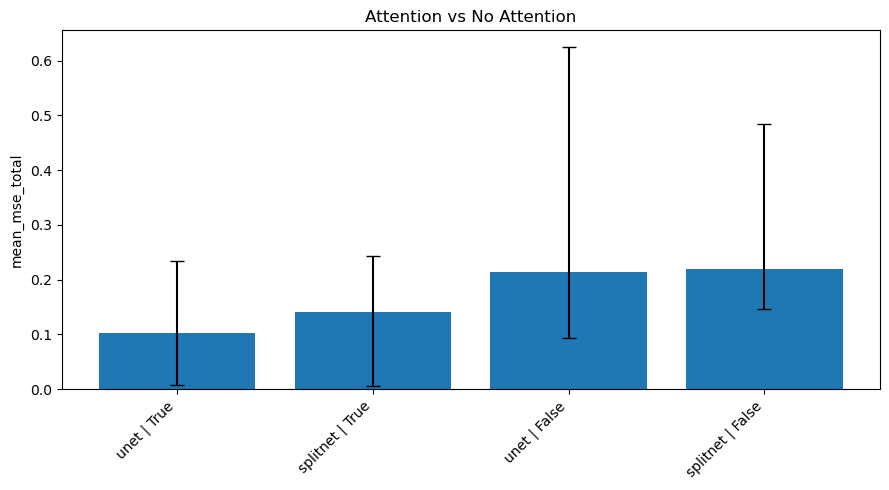


=== Sensor / dataset mode summary ===
  train_dataset_mode  n_models  mean_metric  median_metric  best_metric  \
1              fixed        23     0.107092       0.105469     0.005909   
0             border        23     0.193450       0.146727     0.092613   

   worst_metric  std_metric  
1      0.196318    0.052330  
0      0.623921    0.135986  


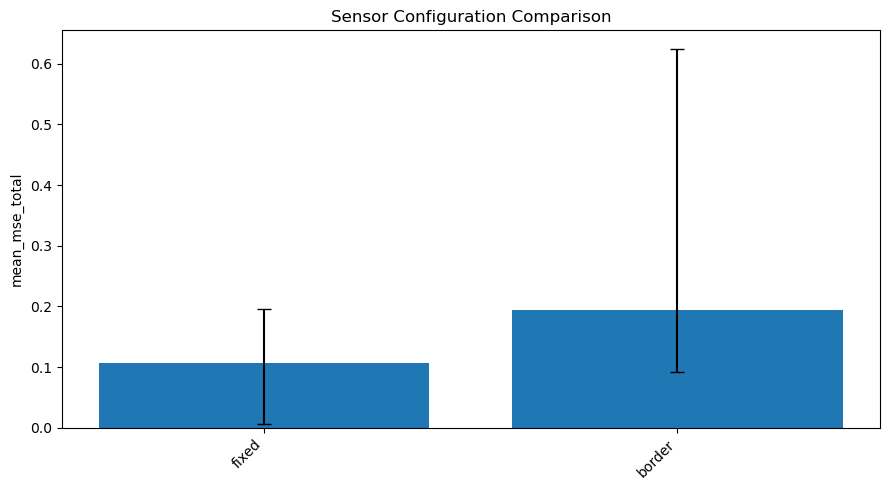


=== Physics-informed vs baseline summary ===
     training_mode  n_models  mean_metric  median_metric  best_metric  \
0    baseline_full         6     0.088733       0.054731     0.005909   
1  physics_limited        40     0.159501       0.123334     0.071680   

   worst_metric  std_metric  
0      0.233621    0.099284  
1      0.623921    0.110642  


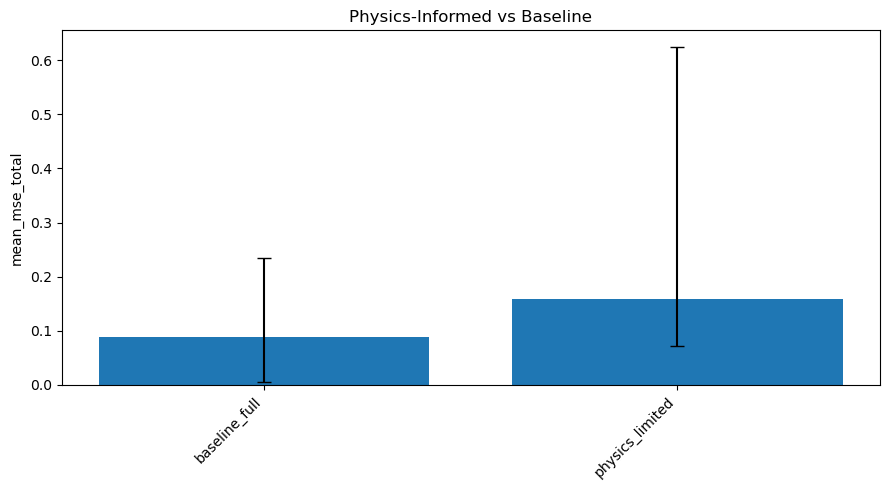


=== Darcy weight summary ===
   darcy_weight  n_models  mean_metric  median_metric  best_metric  \
3          10.0        10     0.116255       0.114061     0.091151   
0           0.1        10     0.133170       0.131816     0.084948   
2           5.0        10     0.192161       0.136664     0.071680   
1           1.0        10     0.196421       0.150849     0.091571   

   worst_metric  std_metric  
3      0.152676    0.022448  
0      0.246728    0.048444  
2      0.484931    0.141310  
1      0.623921    0.157097  


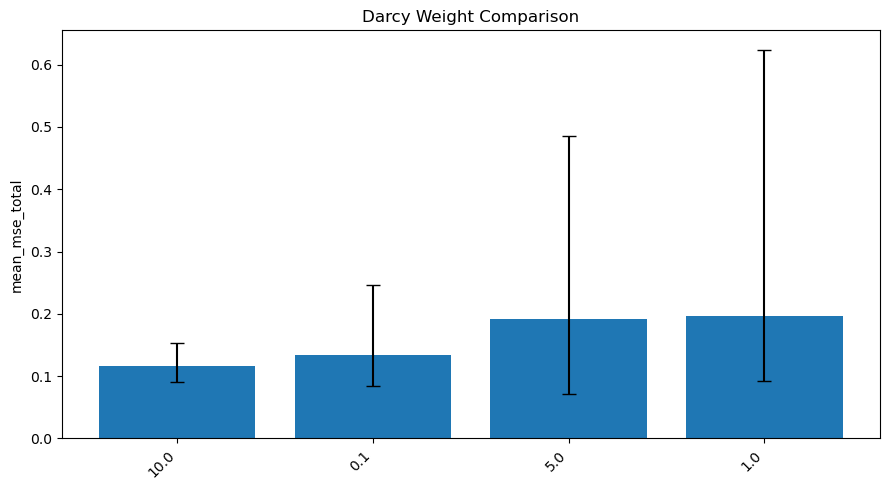

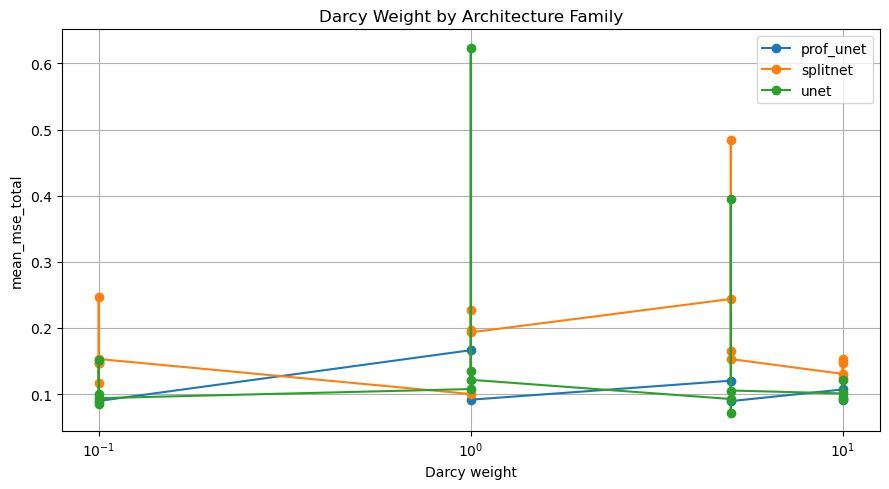



================ QUICK SWEEP MODELS ================
Rows: 90

=== Darcy weight summary ===
   darcy_weight  n_models  mean_metric  median_metric  best_metric  \
5        10.000        15     0.199167       0.140251     0.088307   
4         1.000        15     0.199439       0.140957     0.087576   
1         0.001        15     0.206573       0.142745     0.085251   
2         0.010        15     0.207929       0.156932     0.087615   
3         0.100        15     0.210063       0.157640     0.087121   
0         0.000        15     0.221827       0.164166     0.072725   

   worst_metric  std_metric  
5      0.515749    0.119521  
4      0.763181    0.168907  
1      0.563795    0.146408  
2      0.619392    0.147627  
3      0.512148    0.129718  
0      0.588998    0.149491  


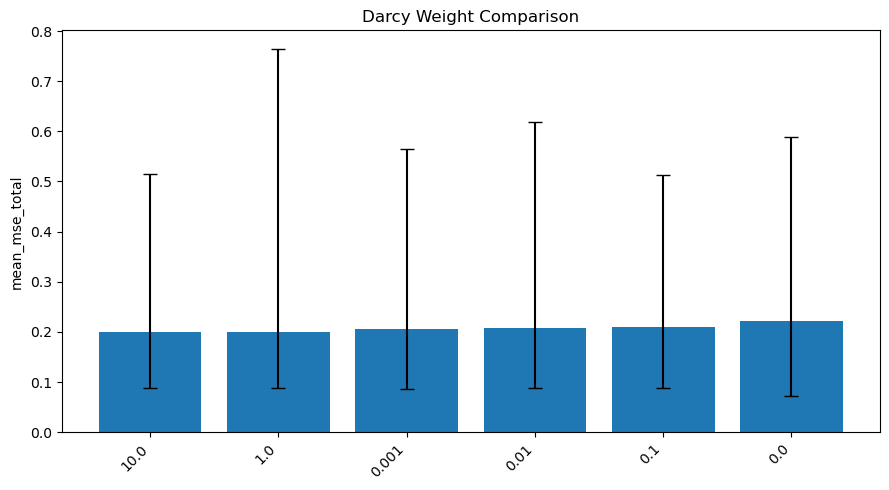

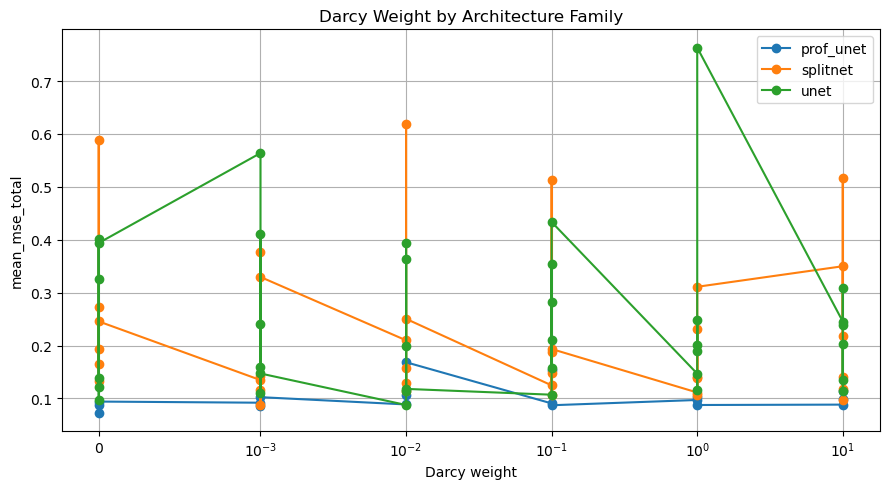



================ DATA AMOUNT MODELS ================
Rows: 19
      model_type    training_mode  n_models  mean_metric  median_metric  \
2      prof_unet    baseline_full         2     0.059127       0.059127   
4  splitnet_attn    baseline_full         2     0.087414       0.087414   
0      attn_unet    baseline_full         2     0.097635       0.097635   
3      prof_unet  physics_limited         4     0.110575       0.108622   
5  splitnet_attn  physics_limited         5     0.168816       0.161713   
1      attn_unet  physics_limited         4     0.269542       0.192127   

   best_metric  worst_metric  std_metric  
2     0.012948      0.105305    0.065306  
4     0.013855      0.160973    0.104028  
0     0.015939      0.179332    0.115536  
3     0.086932      0.138122    0.025237  
5     0.055810      0.308572    0.090729  
1     0.112924      0.580989    0.219609  


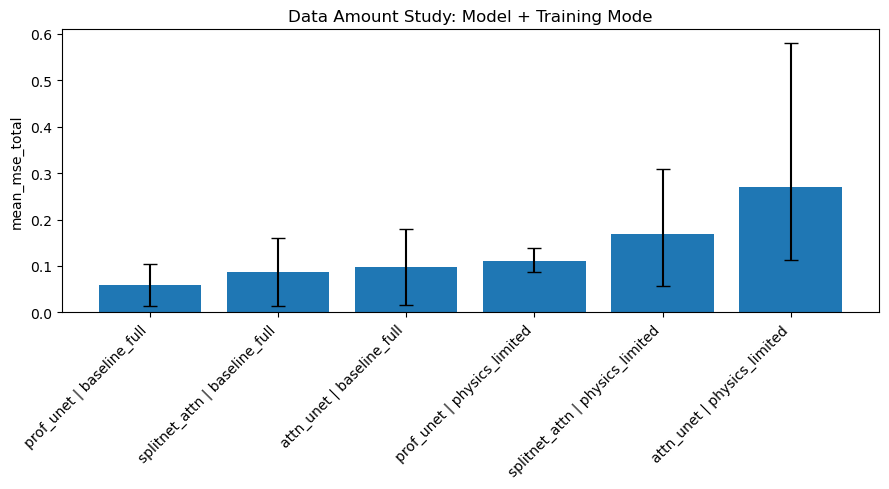

In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# Load / rebuild summary
# -----------------------------------------------------------------------------

def rebuild_summary_csv_from_jsons(
    results_dir="test_eval_outputs",
    out_csv="test_eval_outputs/model_test_summary.csv",
):
    rows = []

    for path in Path(results_dir).rglob("eval_*_summary.json"):
        with open(path, "r") as f:
            summary = json.load(f)

        config = summary.get("config", {})

        rows.append({
            "name": config.get("name", path.stem.replace("eval_", "").replace("_summary", "")),
            "model_type": config.get("model_type"),
            "train_dataset_mode": config.get("train_dataset_mode"),
            "training_mode": config.get("training_mode"),
            "darcy_weight": config.get("darcy_weight"),
            "eval_dataset_mode": config.get("eval_dataset_mode"),
            "model_path": config.get("model_path"),
            "npz_path": summary.get("npz_path"),

            "mean_mse_total": summary.get("mean_mse_total"),
            "mean_nmse_total": summary.get("mean_nmse_total"),
            "mean_darcy": summary.get("mean_darcy"),
            "mean_mse_inmask": summary.get("mean_mse_inmask"),
            "mean_mse_outmask": summary.get("mean_mse_outmask"),
            "mean_mse_k": summary.get("mean_mse_k"),
            "mean_mse_p": summary.get("mean_mse_p"),
            "mean_mae_total": summary.get("mean_mae_total"),
            "mean_bias_total": summary.get("mean_bias_total"),
        })

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df = enrich_df(df).sort_values("name")

    df.to_csv(out_csv, index=False)
    print(f"Saved rebuilt summary CSV with {len(df)} models: {out_csv}")
    return df


def load_summary(summary_csv="test_eval_outputs/model_test_summary.csv"):
    df = pd.read_csv(summary_csv)
    return enrich_df(df)


# -----------------------------------------------------------------------------
# Add useful grouping columns
# -----------------------------------------------------------------------------

def enrich_df(df):
    df = df.copy()

    import re

    def extract_sim_count(name):

        m = re.search(r"sims_(\d+)", str(name))

        if m:

            return int(m.group(1))

        return np.nan

    df["sim_count"] = df["name"].apply(extract_sim_count)
    def arch_family(model_type):
        if model_type in ["splitnet", "splitnet_attn"]:
            return "splitnet"
        if model_type in ["unet", "attn_unet"]:
            return "unet"
        if model_type == "prof_unet":
            return "prof_unet"
        return model_type

    def has_attention(model_type):
        return model_type in ["splitnet_attn", "attn_unet"]

    def experiment_family(name):
        name = str(name)
        if name.startswith("quick_"):
            return "quick_sweep"
        if name.startswith("official_"):
            return "official"
        if name.startswith("baseline_"):
            return "baseline"
        if name.startswith("data_amount_"):
            return "data_amount"
        return "other"

    df["arch_family"] = df["model_type"].apply(arch_family)
    df["has_attention"] = df["model_type"].apply(has_attention)
    df["experiment_family"] = df["name"].apply(experiment_family)

    df["uses_physics"] = df["training_mode"].eq("physics_limited")

    return df


# -----------------------------------------------------------------------------
# Filtering helpers
# -----------------------------------------------------------------------------

def filter_df(
    df,
    experiment_family=None,
    model_type=None,
    arch_family=None,
    has_attention=None,
    train_dataset_mode=None,
    training_mode=None,
    darcy_weight=None,
    contains=None,
):
    out = df.copy()

    if experiment_family is not None:
        out = out[out["experiment_family"].isin(as_list(experiment_family))]

    if model_type is not None:
        out = out[out["model_type"].isin(as_list(model_type))]

    if arch_family is not None:
        out = out[out["arch_family"].isin(as_list(arch_family))]

    if has_attention is not None:
        out = out[out["has_attention"] == has_attention]

    if train_dataset_mode is not None:
        out = out[out["train_dataset_mode"].isin(as_list(train_dataset_mode))]

    if training_mode is not None:
        out = out[out["training_mode"].isin(as_list(training_mode))]

    if darcy_weight is not None:
        out = out[out["darcy_weight"].isin(as_list(darcy_weight))]

    if contains is not None:
        for text in as_list(contains):
            out = out[out["name"].str.contains(text, na=False)]

    return out


def as_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    return [x]


# -----------------------------------------------------------------------------
# Group summaries
# -----------------------------------------------------------------------------

def group_summary(
    df,
    group_cols,
    metric="mean_mse_total",
    lower_is_better=True,
):
    grouped = (
        df.groupby(group_cols)
        .agg(
            n_models=(metric, "count"),
            mean_metric=(metric, "mean"),
            median_metric=(metric, "median"),
            best_metric=(metric, "min" if lower_is_better else "max"),
            worst_metric=(metric, "max" if lower_is_better else "min"),
            std_metric=(metric, "std"),
        )
        .reset_index()
    )

    grouped = grouped.sort_values("mean_metric", ascending=lower_is_better)
    return grouped


def best_and_worst_models(
    df,
    group_cols,
    metric="mean_mse_total",
    lower_is_better=True,
):
    rows = []

    for keys, group in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        sorted_group = group.sort_values(metric, ascending=lower_is_better)
        best = sorted_group.iloc[0]
        worst = sorted_group.iloc[-1]

        row = dict(zip(group_cols, keys))
        row.update({
            "n_models": len(group),
            "best_model": best["name"],
            "best_metric": best[metric],
            "worst_model": worst["name"],
            "worst_metric": worst[metric],
            "mean_metric": group[metric].mean(),
        })

        rows.append(row)

    return pd.DataFrame(rows).sort_values("mean_metric", ascending=lower_is_better)


# -----------------------------------------------------------------------------
# Plots
# -----------------------------------------------------------------------------

def plot_group_summary(
    df,
    group_cols,
    metric="mean_mse_total",
    title=None,
    lower_is_better=True,
):
    summary = group_summary(df, group_cols, metric, lower_is_better)

    labels = summary[group_cols].astype(str).agg(" | ".join, axis=1)
    means = summary["mean_metric"]
    bests = summary["best_metric"]
    worsts = summary["worst_metric"]

    lower_err = means - bests
    upper_err = worsts - means

    plt.figure(figsize=(max(9, len(summary) * 1.1), 5))
    plt.bar(labels, means, yerr=[lower_err, upper_err], capsize=5)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"{metric} grouped by {group_cols}")
    plt.tight_layout()
    plt.show()

    return summary


def plot_group_boxplot(
    df,
    group_col,
    metric="mean_mse_total",
    title=None,
):
    groups = []
    labels = []

    for label, group in df.groupby(group_col):
        vals = group[metric].dropna().values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(str(label))

    plt.figure(figsize=(max(8, len(labels) * 1.1), 5))
    plt.boxplot(groups, labels=labels)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"{metric} by {group_col}")
    plt.tight_layout()
    plt.show()


def plot_darcy_by_group(
    df,
    group_col="model_type",
    metric="mean_mse_total",
    title=None,
):
    plt.figure(figsize=(9, 5))

    for label, group in df.groupby(group_col):
        group = group.sort_values("darcy_weight")
        plt.plot(group["darcy_weight"], group[metric], marker="o", label=str(label))

    plt.xscale("symlog", linthresh=0.001)
    plt.xlabel("Darcy weight")
    plt.ylabel(metric)
    plt.title(title or f"{metric} vs Darcy weight")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Specific comparison reports
# -----------------------------------------------------------------------------

def report_attention_effect(df, metric="mean_mse_total"):
    """
    Compares attention vs no attention while grouping by architecture family.
    Useful for saying: attention helped/hurt on average.
    """
    sub = df[df["model_type"].isin(["splitnet", "splitnet_attn", "unet", "attn_unet"])]

    print("\n=== Attention effect summary ===")
    print(group_summary(sub, ["arch_family", "has_attention"], metric))

    plot_group_summary(
        sub,
        ["arch_family", "has_attention"],
        metric=metric,
        title="Attention vs No Attention",
    )

    return best_and_worst_models(sub, ["arch_family", "has_attention"], metric)


def report_architecture_effect(df, metric="mean_mse_total"):
    """
    Compares SplitNet vs small U-Net vs professor U-Net.
    """
    print("\n=== Architecture family summary ===")
    print(group_summary(df, ["arch_family"], metric))

    plot_group_summary(
        df,
        ["arch_family"],
        metric=metric,
        title="Architecture Comparison",
    )

    return best_and_worst_models(df, ["arch_family"], metric)


def report_sensor_effect(df, metric="mean_mse_total"):
    """
    Compares fixed vs border vs border_pressure training setups.
    """
    print("\n=== Sensor / dataset mode summary ===")
    print(group_summary(df, ["train_dataset_mode"], metric))

    plot_group_summary(
        df,
        ["train_dataset_mode"],
        metric=metric,
        title="Sensor Configuration Comparison",
    )

    return best_and_worst_models(df, ["train_dataset_mode"], metric)


def report_physics_effect(df, metric="mean_mse_total"):
    """
    Compares physics_limited vs baseline_full.
    """
    print("\n=== Physics-informed vs baseline summary ===")
    print(group_summary(df, ["training_mode"], metric))

    plot_group_summary(
        df,
        ["training_mode"],
        metric=metric,
        title="Physics-Informed vs Baseline",
    )

    return best_and_worst_models(df, ["training_mode"], metric)


def report_darcy_effect(df, metric="mean_mse_total"):
    """
    Shows Darcy weight effect for physics models only.
    """
    sub = df[df["training_mode"] == "physics_limited"]

    print("\n=== Darcy weight summary ===")
    print(group_summary(sub, ["darcy_weight"], metric))

    plot_group_summary(
        sub,
        ["darcy_weight"],
        metric=metric,
        title="Darcy Weight Comparison",
    )

    plot_darcy_by_group(
        sub,
        group_col="arch_family",
        metric=metric,
        title="Darcy Weight by Architecture Family",
    )

    return best_and_worst_models(sub, ["darcy_weight"], metric)


# -----------------------------------------------------------------------------
# Preset comparison sets
# -----------------------------------------------------------------------------

def run_main_group_reports(summary_csv="test_eval_outputs/model_test_summary.csv"):
    df = load_summary(summary_csv)

    official = filter_df(
        df,
        experiment_family=["official", "baseline"],
    )

    quick = filter_df(
        df,
        experiment_family="quick_sweep",
    )

    data_amount = filter_df(
        df,
        experiment_family="data_amount",
    )

    print("\n\n================ OFFICIAL / BASELINE MODELS ================")
    print("Rows:", len(official))

    arch_table = report_architecture_effect(official)
    attention_table = report_attention_effect(official)
    sensor_table = report_sensor_effect(official)
    physics_table = report_physics_effect(official)
    darcy_table = report_darcy_effect(official)

    print("\n\n================ QUICK SWEEP MODELS ================")
    print("Rows:", len(quick))

    if len(quick) > 0:
        quick_darcy_table = report_darcy_effect(quick)
    else:
        quick_darcy_table = pd.DataFrame()

    print("\n\n================ DATA AMOUNT MODELS ================")
    print("Rows:", len(data_amount))

    if len(data_amount) > 0:
        data_amount_table = group_summary(
            data_amount,
            ["model_type", "training_mode"],
            metric="mean_mse_total",
        )

        print(data_amount_table)

        plot_group_summary(
            data_amount,
            ["model_type", "training_mode"],
            metric="mean_mse_total",
            title="Data Amount Study: Model + Training Mode",
        )
    else:
        data_amount_table = pd.DataFrame()

    return {
        "official_architecture": arch_table,
        "official_attention": attention_table,
        "official_sensor": sensor_table,
        "official_physics": physics_table,
        "official_darcy": darcy_table,
        "quick_darcy": quick_darcy_table,
        "data_amount": data_amount_table,
    }


# -----------------------------------------------------------------------------
# Example usage
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    summary_csv = "test_eval_outputs/model_test_summary.csv"

    rebuild_summary_csv_from_jsons(
        results_dir="test_eval_outputs",
        out_csv=summary_csv,
    )

    tables = run_main_group_reports(summary_csv)

In [18]:
def plot_data_amount_effect(
    df,
    metric="mean_mse_total",
):
    data = df[df["experiment_family"] == "data_amount"]

    plt.figure(figsize=(8,5))

    for label, group in data.groupby("training_mode"):

        summary = (
            group.groupby("sim_count")[metric]
            .mean()
            .reset_index()
            .sort_values("sim_count")
        )

        plt.plot(
            summary["sim_count"],
            summary[metric],
            marker="o",
            label=label,
        )

    plt.xlabel("Training simulations")
    plt.ylabel(metric)
    plt.title("Performance vs Training Data")
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
def plot_data_amount_by_model(
    df,
    metric="mean_mse_total",
):
    data = df[df["experiment_family"] == "data_amount"]

    plt.figure(figsize=(10,6))

    for label, group in data.groupby(
        ["model_type","training_mode"]
    ):

        summary = (
            group.groupby("sim_count")[metric]
            .mean()
            .reset_index()
            .sort_values("sim_count")
        )

        plt.plot(
            summary["sim_count"],
            summary[metric],
            marker="o",
            label=f"{label[0]} | {label[1]}"
        )

    plt.xlabel("Training simulations")
    plt.ylabel(metric)
    plt.title("Performance vs Data Amount")
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
def plot_physics_gain(df, metric="mean_mse_total"):

    data = df[df["experiment_family"] == "data_amount"]

    rows = []

    for model_type in data["model_type"].unique():

        for sim_count in sorted(data["sim_count"].dropna().unique()):

            subset = data[
                (data["model_type"] == model_type)
                & (data["sim_count"] == sim_count)
            ]

            phys = subset[
                subset["training_mode"]=="physics_limited"
            ][metric]

            base = subset[
                subset["training_mode"]=="baseline_full"
            ][metric]

            if len(phys)==0 or len(base)==0:
                continue

            gain = base.mean() - phys.mean()

            rows.append({
                "model_type": model_type,
                "sim_count": sim_count,
                "gain": gain,
            })

    gains = pd.DataFrame(rows)

    plt.figure(figsize=(8,5))

    for model_type, group in gains.groupby("model_type"):

        group = group.sort_values("sim_count")

        plt.plot(
            group["sim_count"],
            group["gain"],
            marker="o",
            label=model_type,
        )

    plt.axhline(0,color="black")

    plt.xlabel("Training simulations")
    plt.ylabel("Physics Gain")
    plt.title("Benefit of Physics-Informed Training")
    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
summary_csv = "test_eval_outputs/model_test_summary.csv"

# optional, only if you want to rebuild first
rebuild_summary_csv_from_jsons(
    results_dir="test_eval_outputs",
    out_csv=summary_csv,
)

df = load_summary(summary_csv)
df = enrich_df(df)

Saved rebuilt summary CSV with 166 models: test_eval_outputs/model_test_summary.csv


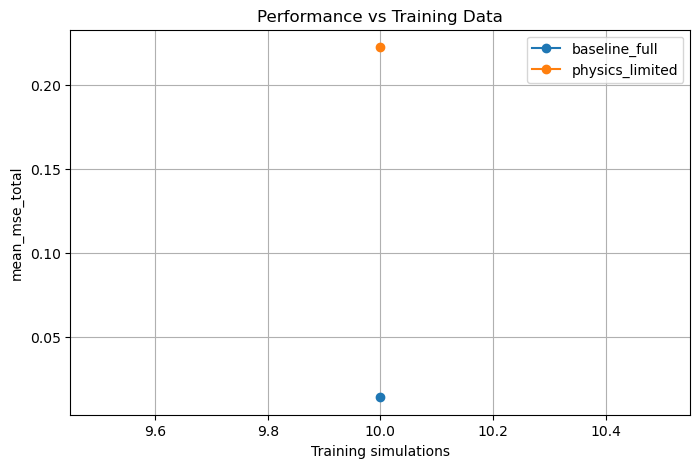

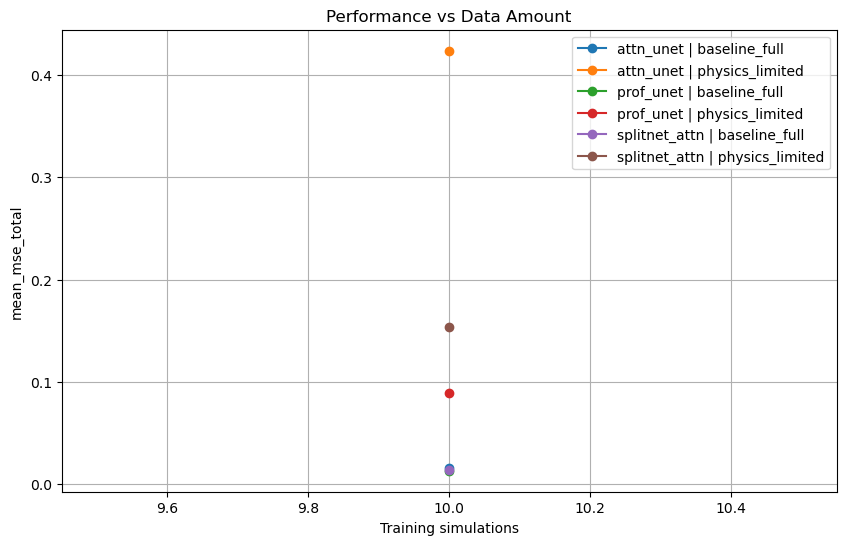

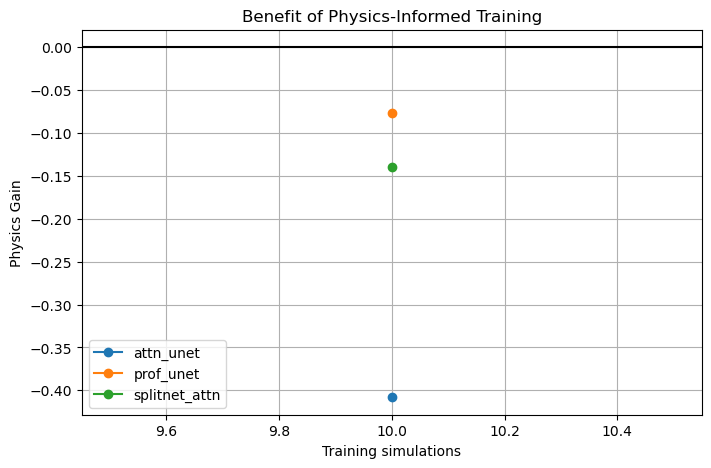

In [12]:
plot_data_amount_effect(df, metric="mean_mse_total")
plot_data_amount_by_model(df, metric="mean_mse_total")
plot_physics_gain(df, metric="mean_mse_total")

In [22]:
data_amount = df[df["experiment_family"] == "data_amount"]

data_amount[
    [
        "name",
        "model_type",
        "training_mode",
        "darcy_weight",
        "sim_count",
        "mean_mse_total",
        "mean_mse_outmask",
        "mean_darcy",
    ]
].sort_values(["sim_count", "model_type", "training_mode"])

,name,model_type,training_mode,darcy_weight,sim_count,mean_mse_total,mean_mse_outmask,mean_darcy
10,data_amount_border_attn_unet_baseline_full_nod...,attn_unet,baseline_full,0.0,10.0,0.179332,0.159393,1.483055e-04
19,data_amount_fixed_attn_unet_baseline_full_noda...,attn_unet,baseline_full,0.0,10.0,0.015939,0.016050,7.359704e-04
11,data_amount_border_attn_unet_physics_limited_d...,attn_unet,physics_limited,10.0,10.0,0.112924,0.088866,1.582401e-04
12,data_amount_border_attn_unet_physics_limited_d...,attn_unet,physics_limited,1.0,10.0,0.117392,0.107401,4.951359e-04
20,data_amount_fixed_attn_unet_physics_limited_da...,attn_unet,physics_limited,10.0,10.0,0.580989,0.576519,4.486140e-07
21,data_amount_fixed_attn_unet_physics_limited_da...,attn_unet,physics_limited,1.0,10.0,0.266862,0.241428,5.973116e-08
13,data_amount_border_prof_unet_baseline_full_nod...,prof_unet,baseline_full,0.0,10.0,0.105305,0.094122,2.220157e-05
22,data_amount_fixed_prof_unet_baseline_full_noda...,prof_unet,baseline_full,0.0,10.0,0.012948,0.013108,1.326296e-03
14,data_amount_border_prof_unet_physics_limited_d...,prof_unet,physics_limited,10.0,10.0,0.125729,0.111338,2.945748e-05
15,data_amount_border_prof_unet_physics_limited_d...,prof_unet,physics_limited,1.0,10.0,0.138122,0.119611,1.980817e-05
